# Telecom Customer Churn Analysis

## Project Overview

Customer churn is a major business problem for telecommunications companies because retaining existing customers is often more valuable than continuously acquiring new ones.

In this project, I analyze customer-level telecom data to:

- Assess and clean data quality
- Explore customer demographics, services, charges, and churn
- Identify factors associated with customer churn
- Perform statistical significance and effect-size analysis
- Engineer business-oriented features
- Segment customers by value and churn status
- Build machine learning models to predict churn
- Evaluate model performance using appropriate classification metrics
- Explain model predictions using feature importance and SHAP
- Apply survival analysis to understand customer retention over time
- Translate analytical findings into actionable business recommendations

The goal is not only to predict which customers may churn, but also to understand **why churn occurs and what the business can do about it**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

## 1. Data Loading

The dataset used in this project is the IBM Telco Customer Churn dataset.

It contains customer-level information covering:

- Demographics
- Account information
- Services subscribed
- Monthly and total charges
- Customer tenure
- Churn status

The dataset will first be loaded into a raw DataFrame. A working copy will then be created so that the original imported data remains preserved.

In [2]:
DATA_URL = (
    "https://raw.githubusercontent.com/"
    "IBM/telco-customer-churn-on-icp4d/master/"
    "data/Telco-Customer-Churn.csv"
)
df_raw = pd.read_csv(DATA_URL)
df = df_raw.copy()

In [3]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 7,043
Columns: 21


In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Initial Data Quality Assessment

Before performing analysis, it is important to understand the structure and quality of the dataset.

The initial assessment checks:

- Data types
- Missing values
- Missing-value percentages
- Number of unique values
- Duplicate records
- Minimum and maximum values

This helps identify potential data-quality problems before analysis and modeling.

In [5]:
def data_quality_report(df):
  report=pd.DataFrame({
      "dtype":df.dtypes.astype(str),
      "missing":df.isna().sum(),
      "missing_pct": df.isna().mean() * 100,
      "unique":df.nunique(),
      "duplicates":df.duplicated().sum(),
      "min":df.min(),
      "max":df.max(),
  })

  return (
      report.sort_values("missing_pct", ascending=False).round(2)
  )


In [6]:
data_quality_report(df)

,dtype,missing,missing_pct,unique,duplicates,min,max
customerID,object,0,0.0,7043,0,0002-ORFBO,9995-HOTOH
gender,object,0,0.0,2,0,Female,Male
SeniorCitizen,int64,0,0.0,2,0,0,1
Partner,object,0,0.0,2,0,No,Yes
Dependents,object,0,0.0,2,0,No,Yes
tenure,int64,0,0.0,73,0,0,72
PhoneService,object,0,0.0,2,0,No,Yes
MultipleLines,object,0,0.0,3,0,No,Yes
InternetService,object,0,0.0,3,0,DSL,No
OnlineSecurity,object,0,0.0,3,0,No,Yes


## 3. Data Cleaning

### 3.1 Standardizing Column Names

Column names are standardized to make them easier to reference consistently in Python.

The cleaning process:

- Removes leading and trailing spaces
- Converts names to lowercase
- Replaces spaces with underscores
- Removes special characters

This creates a consistent naming convention throughout the project.

In [7]:
def clean_column_names(df):
  df=df.copy()
  df.columns=(df.columns.str.strip().str.lower().str.replace(" ","_").str.replace(r"[^a-zA-Z0-9_]", "", regex=True))
  return df

In [8]:
df=clean_column_names(df)
df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 3.2 Converting Numeric Variables

Some numeric variables may be imported as text because of formatting or blank values.

`totalcharges` is converted to a numeric data type using coercion for invalid values.

In [9]:
def convert_numeric_columns(df,columns):
  df=df.copy()
  for col in columns:
    df[col]=pd.to_numeric(df[col],errors="coerce")
  return df


In [10]:
obj_to_num=['totalcharges']

In [11]:
df=convert_numeric_columns(df,obj_to_num)
data_quality_report(df)

,dtype,missing,missing_pct,unique,duplicates,min,max
totalcharges,float64,11,0.16,6530,0,18.8,8684.8
gender,object,0,0.00,2,0,Female,Male
seniorcitizen,int64,0,0.00,2,0,0,1
partner,object,0,0.00,2,0,No,Yes
customerid,object,0,0.00,7043,0,0002-ORFBO,9995-HOTOH
dependents,object,0,0.00,2,0,No,Yes
tenure,int64,0,0.00,73,0,0,72
multiplelines,object,0,0.00,3,0,No,Yes
phoneservice,object,0,0.00,2,0,No,Yes
onlinesecurity,object,0,0.00,3,0,No,Yes


### 3.3 Investigating Missing Total Charges

After conversion, rows where `totalcharges` could not be converted successfully are inspected.

This step helps determine whether the missing values represent data-entry problems, newly acquired customers, or another meaningful pattern.

In [12]:
df[df["totalcharges"].isna()]

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


### 3.4 Duplicate Customer Records

Each customer should have a unique `customerid`.

Duplicate customer IDs are therefore checked and removed so that the analysis does not unintentionally count the same customer multiple times.

In [13]:
def remove_duplicates(df,subset=None):
  before=len(df)
  df=df.drop_duplicates(subset=subset).copy()
  after=len(df)
  print(f"{before-after:,} duplicate rows removed")
  return df
df=remove_duplicates(df,subset="customerid")

0 duplicate rows removed


## 4. Categorical Variable Exploration

Categorical variables describe customer characteristics such as:

- Gender
- Partner and dependent status
- Services subscribed
- Contract type
- Payment method
- Billing preferences
- Churn status

Frequency distributions are examined to understand the composition of the customer base before investigating relationships with churn.

In [14]:
def categorical_summary(df,columns):
  results={}
  for col in columns:
    results[col]=(
        df[col].value_counts(dropna=False).to_dict()
        )
  return results


In [15]:
categorical_cols = [
    'gender','partner','dependents','phoneservice','multiplelines',
    'internetservice','onlinesecurity','onlinebackup','deviceprotection',
    'techsupport','streamingtv','streamingmovies','contract',
    'paperlessbilling','paymentmethod','churn'
]

summary = categorical_summary(df, categorical_cols)
print(summary)

{'gender': {'Male': 3555, 'Female': 3488}, 'partner': {'No': 3641, 'Yes': 3402}, 'dependents': {'No': 4933, 'Yes': 2110}, 'phoneservice': {'Yes': 6361, 'No': 682}, 'multiplelines': {'No': 3390, 'Yes': 2971, 'No phone service': 682}, 'internetservice': {'Fiber optic': 3096, 'DSL': 2421, 'No': 1526}, 'onlinesecurity': {'No': 3498, 'Yes': 2019, 'No internet service': 1526}, 'onlinebackup': {'No': 3088, 'Yes': 2429, 'No internet service': 1526}, 'deviceprotection': {'No': 3095, 'Yes': 2422, 'No internet service': 1526}, 'techsupport': {'No': 3473, 'Yes': 2044, 'No internet service': 1526}, 'streamingtv': {'No': 2810, 'Yes': 2707, 'No internet service': 1526}, 'streamingmovies': {'No': 2785, 'Yes': 2732, 'No internet service': 1526}, 'contract': {'Month-to-month': 3875, 'Two year': 1695, 'One year': 1473}, 'paperlessbilling': {'Yes': 4171, 'No': 2872}, 'paymentmethod': {'Electronic check': 2365, 'Mailed check': 1612, 'Bank transfer (automatic)': 1544, 'Credit card (automatic)': 1522}, 'chur

### 4.1 Encoding the Target Variable

The `churn` variable is originally represented as `"Yes"` and `"No"`.

For statistical analysis and machine learning, it is converted into a binary target:

- `1` = Customer churned
- `0` = Customer did not churn

This makes churn suitable for classification models and numerical analysis.

In [16]:
df['churn']=(
    df['churn'].str.strip().str.lower()
    .map({"yes":1,"no":0})
)

round(df["churn"].value_counts(normalize=True)*100,2)

,proportion
churn,
0,73.46
1,26.54


### 4.2 Overall Churn Distribution

The overall distribution of the target variable is visualized to understand the proportion of customers who churned versus those who remained.

This is particularly important for assessing potential class imbalance before developing predictive models.

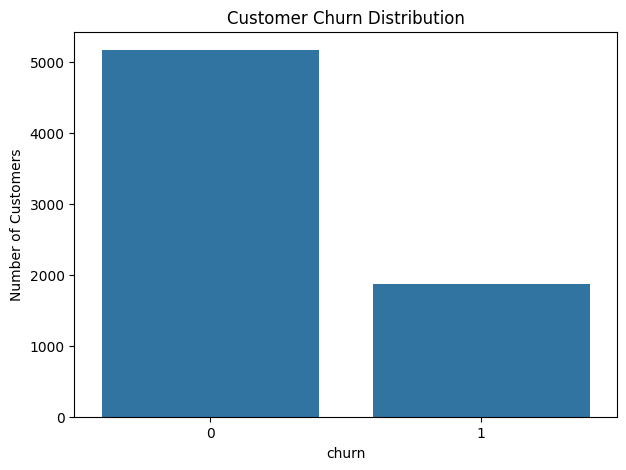

In [17]:
def plot_target_distribution(df,target):
  plt.figure(figsize=(7,5))
  sns.countplot(data=df,x=target)
  plt.title("Customer Churn Distribution")
  plt.ylabel("Number of Customers")
  plt.show()
plot_target_distribution(df,"churn")

## 5. Churn Analysis by Customer Category

Overall churn rate does not explain which customer groups are more affected.

Churn rates are therefore calculated across important categorical variables such as:

- Contract type
- Internet service
- Payment method

Groups with very small customer counts are excluded from the comparison to reduce the risk of drawing conclusions from unstable estimates.

In [18]:
def churn_rate_by_category(df,category,target="churn",min_count=30):
  result=(
      df.groupby(category).agg(
          customers=(target,"size"),
          churn_rate=(target,"mean")
      )
      .reset_index()
  )
  result["churn_rate"]*=100
  return (
      result[result["customers"]>=min_count]
      .sort_values("churn_rate",ascending=False)
      .round(2)
  )

In [19]:
churn_rate_by_category(df, "contract")

,contract,customers,churn_rate
0,Month-to-month,3875,42.71
1,One year,1473,11.27
2,Two year,1695,2.83


In [20]:
churn_rate_by_category(df, "internetservice")

,internetservice,customers,churn_rate
1,Fiber optic,3096,41.89
0,DSL,2421,18.96
2,No,1526,7.40


In [21]:
churn_rate_by_category(df, "paymentmethod")

,paymentmethod,customers,churn_rate
2,Electronic check,2365,45.29
3,Mailed check,1612,19.11
0,Bank transfer (automatic),1544,16.71
1,Credit card (automatic),1522,15.24


### 5.1 Visualizing Category-Level Churn

Bar charts are used to compare churn rates across customer categories.

The purpose is descriptive: these visualizations help identify patterns that can later be investigated using statistical tests.

In [22]:
def plot_churn_rate(df,category,target="churn"):
  summary=churn_rate_by_category(df,category,target)
  plt.figure(figsize=(7,5))
  sns.barplot(data=summary,x="churn_rate",y=category)
  plt.title(f"Churn Rate by {category}")
  plt.xlabel("Churn Rate (%)")
  plt.ylabel(category)
  plt.show()

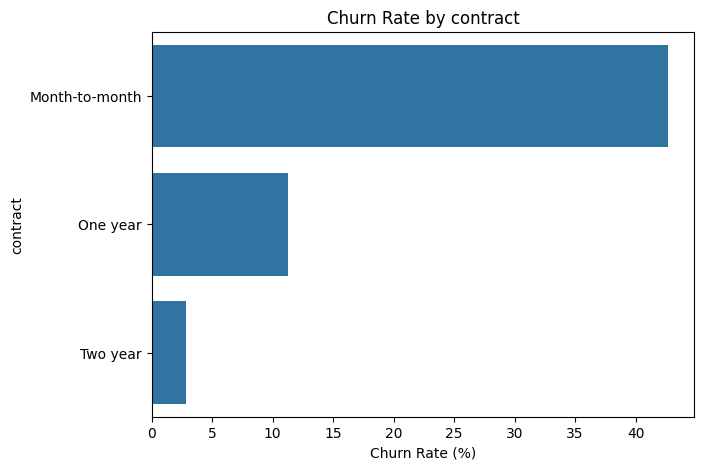

In [23]:
plot_churn_rate(df, "contract")

## 6. Numerical Feature Analysis

Numerical variables such as tenure, monthly charges, and total charges are compared between customers who churned and customers who remained.

Mean, median, and standard deviation are examined because customer-level financial and tenure variables may be skewed, making the median particularly useful for comparison.

In [24]:
def numeric_churn_summary(df,columns,target="churn"):
  return(
      df.groupby(target)[columns].agg(["mean","median","std"])
      .round(2)
  )
numeric_churn_summary(df,["tenure","monthlycharges","totalcharges"])

tenure               monthlycharges               totalcharges           \
        mean median    std           mean median    std         mean   median   
churn                                                                           
0      37.57   38.0  24.11          61.27  64.43  31.09      2555.34  1683.60   
1      17.98   10.0  19.53          74.44  79.65  24.67      1531.80   703.55   

                
           std  
churn           
0      2329.46  
1      1890.82

### 6.1 Numerical Distributions by Churn Status

Distribution plots are used to examine how numerical variables differ between churned and non-churned customers.

These visualizations help identify:

- Differences in central tendency
- Distribution shape
- Potential skewness
- Overlapping ranges between churn groups

In [25]:
def plot_numeric_by_target(df,column,target="churn"):
  plt.figure(figsize=(9,5))
  sns.histplot(data=df,x=column,hue=target,kde=True,element="step",stat="density",common_norm=False)
  plt.title(f"{column.title()} Distribution by Churn")
  plt.show()


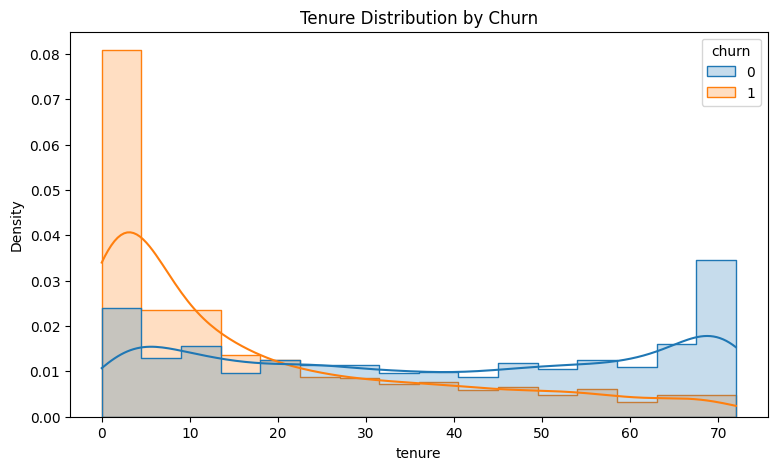

In [26]:
plot_numeric_by_target(df, "tenure")

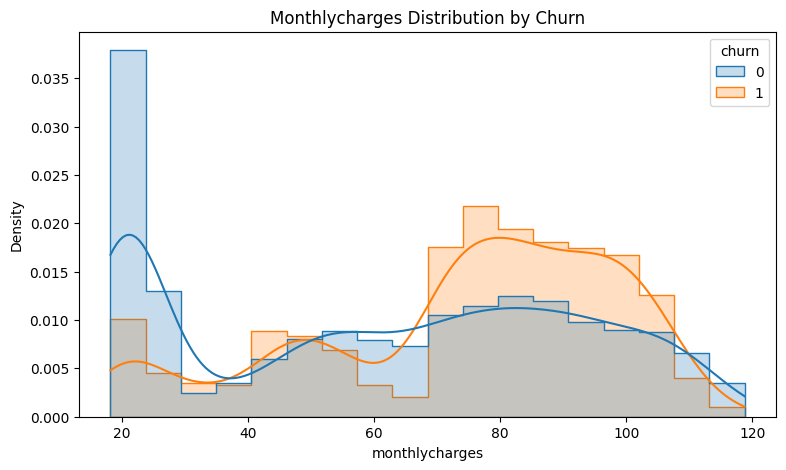

In [27]:
plot_numeric_by_target(df, "monthlycharges")

## 7. Correlation Analysis

Correlation analysis is used to examine relationships among numerical variables.

This can reveal:

- Strong relationships between features
- Potential redundancy
- Variables that may contain similar information

Correlation does **not** imply causation, so these results are interpreted as associations rather than causal relationships.

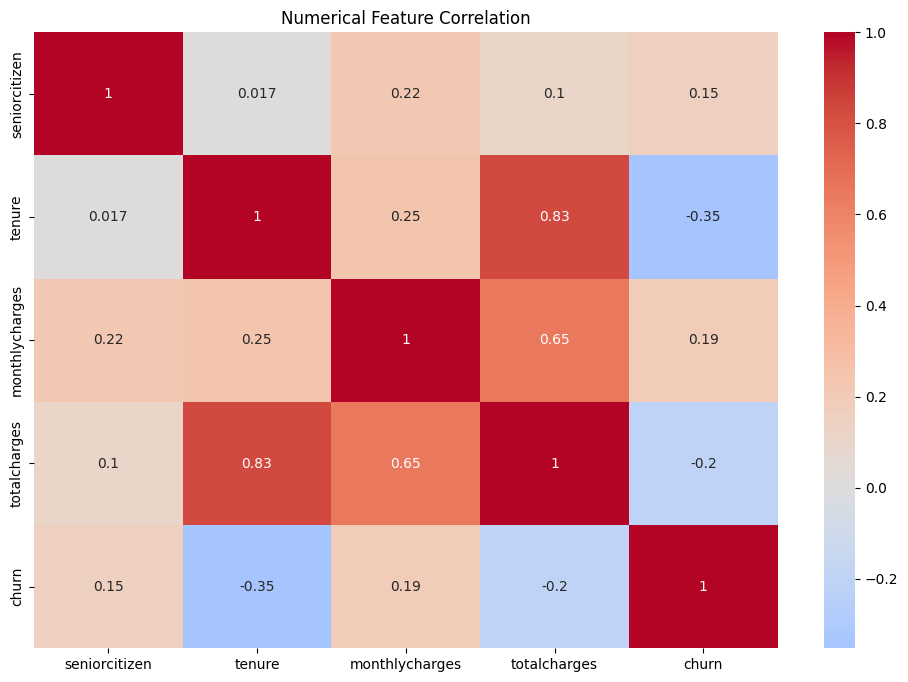

In [28]:
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Numerical Feature Correlation")
plt.show()

## 8. Statistical Significance Testing

Visual differences between customer groups do not necessarily indicate statistically meaningful relationships.

### 8.1 Chi-Square Test of Independence

The Chi-Square test is used to test whether a categorical feature and churn are statistically associated.

### Hypotheses

**H₀:** The categorical feature and churn are independent.

**H₁:** The categorical feature and churn are associated.

A small p-value provides evidence against the null hypothesis.

However, statistical significance alone does not tell us how strong the relationship is, so effect size will also be calculated.

In [29]:
def chi_square_test(df,feature,target="churn"):
  contingency=pd.crosstab(df[feature],df[target])
  chi2, p, dof, expected = stats.chi2_contingency(contingency)
  return  {
      "feature":feature,
      "chi2":chi2,
      "p":p,
      "dof":dof,
      "expected":expected
  }

In [30]:
categorical_cols = [
    "contract",
    "internetservice",
    "paymentmethod",
    "techsupport",
    "onlinesecurity",
    "paperlessbilling"
]


In [31]:
results=pd.DataFrame([chi_square_test(df,feature) for feature in categorical_cols])
results


,feature,chi2,p,dof,expected
0,contract,1184.596572,5.863038e-258,2,"[[2846.6917506744285, 1028.3082493255715], [10..."
1,internetservice,732.309590,9.571788e-160,2,"[[1778.5395428084623, 642.4604571915377], [227..."
2,paymentmethod,648.142327,3.682355e-140,3,"[[1134.2689194945335, 409.7310805054664], [111..."
3,techsupport,828.197068,1.443084e-180,2,"[[2551.370438733494, 921.6295612665058], [1121..."
4,onlinesecurity,849.998968,2.661150e-185,2,"[[2569.736191963652, 928.2638080363481], [1121..."
5,paperlessbilling,258.277649,4.073355e-58,1,"[[2109.8577310805053, 762.1422689194945], [306..."


### 8.2 Cramér's V Effect Size

Cramér's V measures the strength of association between two categorical variables.

This complements the Chi-Square test:

- Chi-Square / p-value → Is there evidence of an association?
- Cramér's V → How strong is the association?

Using both prevents us from treating statistical significance as evidence of a practically important relationship.

In [32]:
def cramers_v(df,feature,target="churn"):
  contingency=pd.crosstab(df[feature],df[target])
  chi2= stats.chi2_contingency(contingency)[0]
  n=contingency.sum().sum()
  min_dim=min(contingency.shape)-1
  return np.sqrt((chi2/n)/min_dim)


In [33]:
effect_results=pd.DataFrame(
    {
        "feature":categorical_cols,
        "cramers_v":[
            cramers_v(df,feature) for feature in categorical_cols
        ]
    })


effect_results.sort_values("cramers_v",ascending=False)

,feature,cramers_v
0,contract,0.410116
4,onlinesecurity,0.347400
3,techsupport,0.342916
1,internetservice,0.322455
2,paymentmethod,0.303359
5,paperlessbilling,0.191498


## 9. Business-Oriented Feature Engineering

The analysis is extended beyond statistical exploration by creating features that have direct business interpretation.

These engineered variables estimate customer revenue and compare expected charges with recorded total charges.

The purpose is to transform raw variables into metrics that can support business analysis and decision-making.

In [34]:
df["estimated_annual_revenue"]=(df["monthlycharges"] * 12).round(2)
df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,estimated_annual_revenue
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,358.2
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,0,683.4
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,646.2
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,507.6
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,848.4


### 9.1 Estimated Annual Revenue

Estimated annual revenue is calculated from monthly charges.

This provides a simple customer-level approximation of annual recurring revenue under the assumption that the customer's current monthly charge remains constant for 12 months.

In [35]:
df["estimated_total_charges"] = (
    df["tenure"] * df["monthlycharges"]
).round(2)
df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,estimated_annual_revenue,estimated_total_charges
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,358.2,29.85
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,0,683.4,1936.30
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,646.2,107.70
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,507.6,1903.50
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,848.4,141.40


### 9.2 Estimated vs Recorded Total Charges

Estimated total charges are calculated as:

**Tenure × Monthly Charges**

This estimate is compared with the recorded `totalcharges` value.

The difference can help identify discrepancies caused by factors such as changes in monthly charges, discounts, service changes, or billing timing.

In [36]:
df["charge_difference"] = (
    df["estimated_total_charges"] - df["totalcharges"]
).round(2)
df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,estimated_annual_revenue,estimated_total_charges,charge_difference
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,358.2,29.85,0.00
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,0,683.4,1936.30,46.80
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,646.2,107.70,-0.45
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,507.6,1903.50,62.75
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,848.4,141.40,-10.25


## 10. Data Quality Validation

After the initial cleaning process, additional validation checks are performed to verify that the dataset is suitable for analysis.

These checks include:

- Remaining missing values
- Unique-value counts
- Invalid numerical ranges
- Statistical consistency
- Potential business-rule violations

In [37]:
def missing_value_report(df):
  return (
      df.isna().sum().to_frame("missing_count").assign(missing_pct=lambda x:(x["missing_count"]/len(df)*100).round(2))
      .query("missing_count>0")
      .sort_values("missing_count",ascending=False)
  )


In [38]:
missing_value_report(df)

,missing_count,missing_pct
totalcharges,11,0.16
charge_difference,11,0.16


### 10.1 Unique Value Validation

Unique-value counts are reviewed for important categorical and identifier variables.

This helps identify unexpected categories, incorrectly imported values, or variables with insufficient variation.

In [39]:
def unique_value_report(df,columns):
  return pd.DataFrame({
      col:df[col].nunique() for col in columns
  }).T.rename(columns={0:"unique_count"})

### 10.2 Numerical Range Validation

Basic business rules are used to identify impossible or suspicious numerical values.

For example:

- Tenure should not be negative.
- Monthly charges should not be negative.
- Total charges should not be negative.

These checks help detect values that could distort analysis or model training.

In [40]:
def validate_numeric_ranges(df):
  checks={
      "negative_tenure":(df["tenure"]<0).sum(),
      "negative_monthly_charges":(df["monthlycharges"]<0).sum(),
      "negative_total_charges":(df["totalcharges"]<0).sum(),
        }
  return pd.Series(checks)
validate_numeric_ranges(df)

,0
negative_tenure,0
negative_monthly_charges,0
negative_total_charges,0


## 11. Non-Parametric Statistical Testing

### Mann-Whitney U Test

The Mann-Whitney U test is used to compare the distributions of numerical variables between churned and non-churned customers.

It is useful when the assumptions required for a traditional independent-samples t-test may not be appropriate, particularly when variables are skewed or contain outliers.

### Hypotheses

**H₀:** The distributions of the two groups are equivalent.

**H₁:** The distributions differ between the two groups.

The p-value is interpreted alongside the actual group statistics rather than being treated as a measure of business importance.

In [41]:
def mann_whitney_test(df,feature,target="churn"):
  group0=df[df[target]==0][feature].dropna()
  group1=df[df[target]==1][feature].dropna()
  stat,p=stats.mannwhitneyu(group0,group1,alternative="two-sided")
  return {
      "feature":feature,
      "stat":stat,
      "p":p
  }



In [42]:
numeric_feautures=[
    "tenure",
    "monthlycharges",
    "totalcharges"
]
mannwhitneyu_results=pd.DataFrame([
    mann_whitney_test(df,feature) for feature in numeric_feautures
])
mannwhitneyu_results


,feature,stat,p
0,tenure,7154668.0,2.419636e-208
1,monthlycharges,3667080.5,3.311628e-54
2,totalcharges,6288982.0,1.995985e-84


## 12. Business-Level Churn Summary

Statistical analysis is translated into business metrics by comparing customers who churned with customers who remained.

The summary includes:

- Customer count
- Average monthly charges
- Total monthly revenue represented by each group
- Average total charges

This provides a high-level view of the potential financial significance of customer churn.

In [43]:
def business_summary(df):
  return (
      df.groupby("churn").agg(
          customers=("customerid","count"),
          avg_monthly_charges=("monthlycharges","mean"),
          total_monthly_revenue=("monthlycharges","sum"),
          avg_total_charges=("totalcharges","mean"),

  ).round(2)
  )
business_summary(df)

,customers,avg_monthly_charges,total_monthly_revenue,avg_total_charges
churn,,,,
0,5174,61.27,316985.75,2555.34
1,1869,74.44,139130.85,1531.80


## 13. Customer Segmentation

Customer segmentation combines analytical findings with business context.

Customers are segmented into:

### Value Segment
Based on total charges:

- Low-value
- Medium-value
- High-value

### Risk Segment
Based on churn status:

- Active
- Churned

Cross-tabulating these segments helps identify how customer value and churn status intersect.

In [44]:
def create_customer_segment(df):
  df=df.copy()
  df["value_segment"]=pd.qcut(df["totalcharges"],q=3,labels=["low","medium","high"])
  df["risk_segment"]=np.select([
      df["churn"]==1,
      df["churn"]==0
  ],["Churned","Active"],default="Unknown"

  )
  return df

In [45]:
df=create_customer_segment(df)
df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,estimated_annual_revenue,estimated_total_charges,charge_difference,value_segment,risk_segment
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Yes,Electronic check,29.85,29.85,0,358.2,29.85,0.00,low,Active
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,Mailed check,56.95,1889.50,0,683.4,1936.30,46.80,medium,Active
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Yes,Mailed check,53.85,108.15,1,646.2,107.70,-0.45,low,Churned
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,Bank transfer (automatic),42.30,1840.75,0,507.6,1903.50,62.75,medium,Active
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Yes,Electronic check,70.70,151.65,1,848.4,141.40,-10.25,low,Churned


### 13.1 Value × Risk Analysis

The cross-tabulation shows the proportion of customers within each value segment who are active or churned.

This helps answer a business question:

> Are higher-value customers also represented among customers who churn?

The result can help prioritize further investigation into customer retention and potential revenue exposure.

In [46]:
pd.crosstab(df["value_segment"],df["risk_segment"],normalize="index").round(3)

risk_segment,Active,Churned
value_segment,,
low,0.605,0.395
medium,0.763,0.237
high,0.835,0.165


# 14. Predictive Modeling

The analysis now moves from understanding historical churn patterns to predicting customer churn.

The objective is to build classification models that estimate the probability that a customer will churn based on their demographic, service, account, tenure, and billing characteristics.

The modeling workflow will include:

1. Defining features and the target variable
2. Splitting the data into training and testing sets
3. Preprocessing numerical and categorical variables
4. Training classification models
5. Evaluating model performance
6. Comparing different models
7. Interpreting model predictions

The first model will be Logistic Regression because it provides a relatively simple and interpretable baseline before more complex models are introduced.

In [47]:
target="churn"
x=df.drop(columns=[target,"customerid","risk_segment","value_segment"])
y=df[target]
print("Feature shape:",x.shape)
print("Target shape:",y.shape)

Feature shape: (7043, 22)
Target shape: (7043,)


In [48]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)
print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 5634
Testing rows: 1409


### 14.1 Feature Preprocessing

The dataset contains both numerical and categorical variables.

Numerical variables can be used directly by many machine learning algorithms, while categorical variables must be converted into a numerical representation.

Categorical features will therefore be one-hot encoded.

Preprocessing will be performed inside a scikit-learn pipeline so that transformations are learned only from the training data and consistently applied to the test data.

In [49]:
numeric_features=X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features=X_train.select_dtypes(exclude=np.number).columns.tolist()
print("Numeric features:",numeric_features)
print("Categorical features:",categorical_features)

Numeric features: ['seniorcitizen', 'tenure', 'monthlycharges', 'totalcharges', 'estimated_annual_revenue', 'estimated_total_charges', 'charge_difference']
Categorical features: ['gender', 'partner', 'dependents', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod']


### Building the Preprocessing Pipelines

The numerical and categorical features require different preprocessing steps.

For numerical features:
- Missing values are replaced using the median.
- Features are standardized using `StandardScaler`.

For categorical features:
- Missing values are replaced using the most frequent category.
- Categories are converted into numerical form using one-hot encoding.

Using separate pipelines keeps the preprocessing steps organized and ensures that the same transformations are consistently applied during model training and prediction.

In [50]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_transformer=Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])

categorical_transformer=Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("onehot",OneHotEncoder(handle_unknown="ignore"))
])

### Combining Numerical and Categorical Preprocessing

A `ColumnTransformer` is used to apply the appropriate preprocessing pipeline to each group of features.

- Numerical columns are processed using the numerical pipeline.
- Categorical columns are processed using the categorical pipeline.

This creates a single preprocessing object that can be integrated directly into the machine learning model.

In [51]:
from sklearn.compose import ColumnTransformer

preprocessor=ColumnTransformer(
    transformers=[
        ("num",numeric_transformer,numeric_features),
        ("cat",categorical_transformer,categorical_features)
    ]
)

### Training the Logistic Regression Model

Logistic Regression is used as the first classification model because it provides a relatively simple and interpretable baseline for predicting customer churn.

The preprocessing steps and model are combined into a single pipeline. This ensures that the same preprocessing applied during training is also applied when making predictions on new data.

The model is then fitted using the training dataset.

In [52]:
from sklearn.linear_model import LogisticRegression

logistic_model=Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("model",LogisticRegression(max_iter=1000))
])
logistic_model.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['seniorcitizen', 'tenure',
                                                   'monthlycharges',
                                                   'totalcharges',
                                                   'estimated_annual_revenue',
                                                   'estimated_total_charges',
                                                   'charge_difference']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'partner',
                                                   'dependents', 'phoneservice',
                                                   'multiplelines',
                                                   'internetservice',
                                                   'onlinesecurity',
                                                   'onlinebackup',
                                                   'deviceprotection',
                                                   'techsupport', 'streamingtv',
                                                   'streamingmovies',
                                                   'contract',
                                                   'paperlessbilling',
                                                   'paymentmethod'])])),
                ('model', LogisticRegression(max_iter=1000))])

### Generating Churn Predictions

The trained Logistic Regression model is used to make predictions on the unseen test dataset.

Two types of predictions are generated:

- `y_pred` contains the predicted class: `0` for no churn and `1` for churn.
- `y_proba` contains the predicted probability of churn for each customer.

The probability scores are useful for evaluating how well the model distinguishes between customers who churn and those who do not.

In [53]:
y_pred=logistic_model.predict(X_test)
y_proba=logistic_model.predict_proba(X_test)[:,1]


### Classification Report

The classification report is used to evaluate the model's predictions across several classification metrics.

It reports:

- **Precision** — the proportion of customers predicted to churn who actually churned.
- **Recall** — the proportion of actual churned customers that the model correctly identified.
- **F1-score** — the harmonic mean of precision and recall.
- **Support** — the number of actual observations in each class.

These metrics provide a more detailed view of model performance than accuracy alone.

In [54]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



### ROC-AUC Evaluation

ROC-AUC is used to evaluate how well the model separates customers who churn from customers who do not churn across different classification thresholds.

The ROC-AUC score summarizes the model's ability to distinguish between the two classes using predicted probabilities.

A higher ROC-AUC indicates better separation between churned and non-churned customers.

In [55]:
from sklearn.metrics import roc_auc_score
roc_auc=roc_auc_score(y_test,y_proba)
print("ROC AUC:",roc_auc)

ROC AUC: 0.8417344803534061


### PR-AUC Evaluation

Precision-Recall AUC (PR-AUC) evaluates the relationship between precision and recall across different classification thresholds.

This metric is particularly useful when the positive class is less common, as is the case with customer churn in this dataset.

The PR-AUC score summarizes how effectively the model identifies churned customers while maintaining precision.

In [56]:
from sklearn.metrics import average_precision_score
pr_auc=average_precision_score(y_test,y_proba)
print("PR AUC:",pr_auc)

PR AUC: 0.6322803099862242
